# Pockels Cell Readout Correction

SLUG's Channel 4 signal is optical transmission through a Pockels-cell modulator, not
the true electrical pulse -- see `shot_characterization/pockels.py` for the full model
and where every constant comes from.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shot_log as sl
from helpers import load_channel
from shot_characterization import characterize, find_xray_shape, find_proton_onset, correct_pockels_signal
from shot_characterization.characterize import regions_above


## Check on one shot

Shot 9 first: it has a logged EOM bias voltage (1.2V) and no flat-top plateau of its
own, so it exercises the harder, more model-dependent path (Vmax derived from the
bias-point prediction rather than an independent measurement).

shot 9: Vmax=68.89mV (Vmax floor applied)  256 unstable samples  raw TOF=12.500ns  corrected TOF=12.547ns


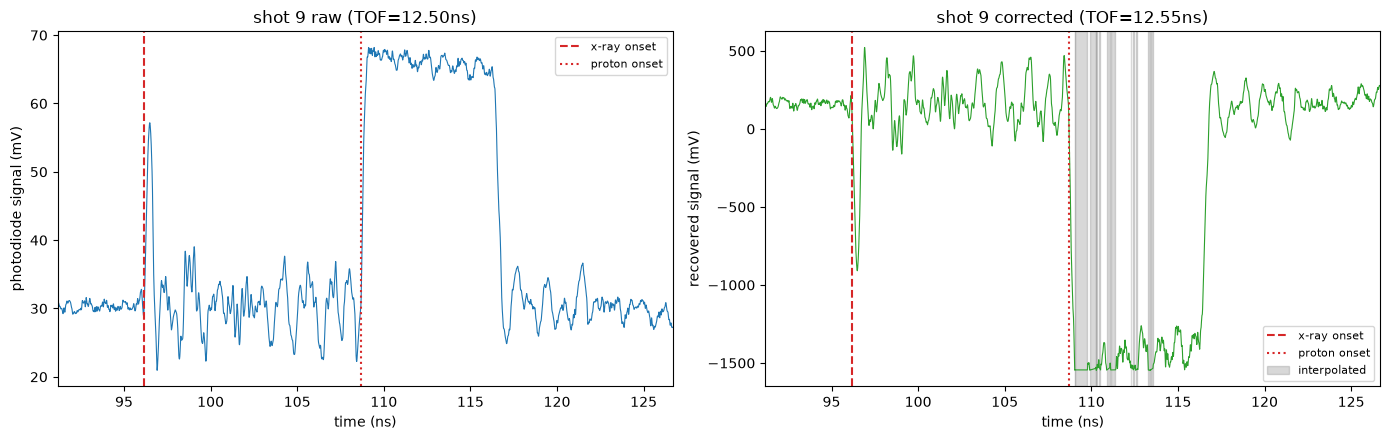

In [2]:
def load_and_correct(shot, V_bias):
    entry = sl.main_channel_entry(shot)
    kind, path, ch = entry
    t, v, clipped, ydisp = load_channel(sl.DATA_DIR, kind, path, ch)
    t_ns = t * 1e9
    # reuse characterize()'s own baseline (median of the first ~20% of samples)
    # rather than a hardcoded time window -- shots differ in where their onset
    # sits (shot 9 onsets ~96ns, but shots 19/20/21/27 onset near t=0ns), so a
    # fixed "t_ns < 90" window silently averaged the pulse itself into the
    # baseline for those shots, corrupting Vmax
    V_baseline = characterize(t, v, clipped)["baseline_V"]
    result = correct_pockels_signal(t, v, V_bias=V_bias, V_baseline=V_baseline)
    return t, v, clipped, t_ns, result


def plot_shot_correction(shot, V_bias):
    t, v, clipped, t_ns, result = load_and_correct(shot, V_bias)
    v_c = result["v_signal"]

    res_raw = characterize(t, v, clipped)
    xr_raw = find_xray_shape(t, v, res_raw["baseline_V"], res_raw["noise_V"])
    pr_raw = find_proton_onset(t, v, res_raw["baseline_V"], xr_raw["peak_i"])

    res_c = characterize(t, v_c, clipped)
    xr_c = find_xray_shape(t, v_c, res_c["baseline_V"], res_c["noise_V"])
    pr_c = find_proton_onset(t, v_c, res_c["baseline_V"], xr_c["peak_i"])

    tof_raw = pr_raw["onset_time_ns"] - xr_raw["onset_time_ns"]
    tof_c = pr_c["onset_time_ns"] - xr_c["onset_time_ns"]
    floor_note = " (Vmax floor applied)" if result["vmax_floor_applied"] else ""
    print(f"shot {shot}: Vmax={result['Vmax']*1000:.2f}mV{floor_note}  "
          f"{result['unstable_mask'].sum()} unstable samples  "
          f"raw TOF={tof_raw:.3f}ns  corrected TOF={tof_c:.3f}ns")

    lo, hi = xr_raw["onset_time_ns"] - 5, pr_raw["end_time_ns"] + 10
    mask = (t_ns >= lo) & (t_ns <= hi)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)

    ax = axes[0]
    ax.plot(t_ns[mask], v[mask]*1000, lw=0.8, color="tab:blue")
    ax.axvline(xr_raw["onset_time_ns"], color="tab:red", ls="--", label="x-ray onset")
    ax.axvline(pr_raw["onset_time_ns"], color="tab:red", ls=":", label="proton onset")
    ax.set_title(f"shot {shot} raw (TOF={tof_raw:.2f}ns)")
    ax.set_xlabel("time (ns)"); ax.set_ylabel("photodiode signal (mV)")
    ax.set_xlim(lo, hi)
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.plot(t_ns[mask], v_c[mask]*1000, lw=0.8, color="tab:green")
    ax.axvline(xr_c["onset_time_ns"], color="tab:red", ls="--", label="x-ray onset")
    ax.axvline(pr_c["onset_time_ns"], color="tab:red", ls=":", label="proton onset")
    # shade each contiguous unstable run separately -- a single min-to-max
    # span would make a few scattered short runs look like one big unreliable
    # block, which isn't what's actually happening (checked directly: shot 19
    # has only 3 runs of 7-12 samples each, not one continuous stretch)
    labeled = False
    for s, e in regions_above(result["unstable_mask"]):
        if t_ns[e - 1] < lo or t_ns[s] > hi:
            continue
        ax.axvspan(t_ns[s], t_ns[e - 1], color="gray", alpha=0.3,
                   label="interpolated" if not labeled else None)
        labeled = True
    ax.set_title(f"shot {shot} corrected (TOF={tof_c:.2f}ns)")
    ax.set_xlabel("time (ns)"); ax.set_ylabel("recovered signal (mV)")
    ax.set_xlim(lo, hi)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return dict(shot=shot, V_bias=V_bias, Vmax_mV=result["Vmax"]*1000,
                n_unstable=int(result["unstable_mask"].sum()),
                tof_raw_ns=tof_raw, tof_corrected_ns=tof_c)


_ = plot_shot_correction(9, 1.2)


## Every double-pulse shot with a logged EOM bias voltage

Correcting requires knowing the shot's EOM bias voltage, which is logged in the
Titan/MDEC shot log -- but only for some of the 10 usable double-pulse shots.
Checked directly: shots 15, 16, 18, 22 have no logged bias voltage at all, so they're
skipped here rather than guessed at. That leaves 6 shots: 9, 11, 19, 20, 21, 27.

shot 11: Vmax=105.28mV (Vmax floor applied)  2 unstable samples  raw TOF=13.250ns  corrected TOF=13.250ns


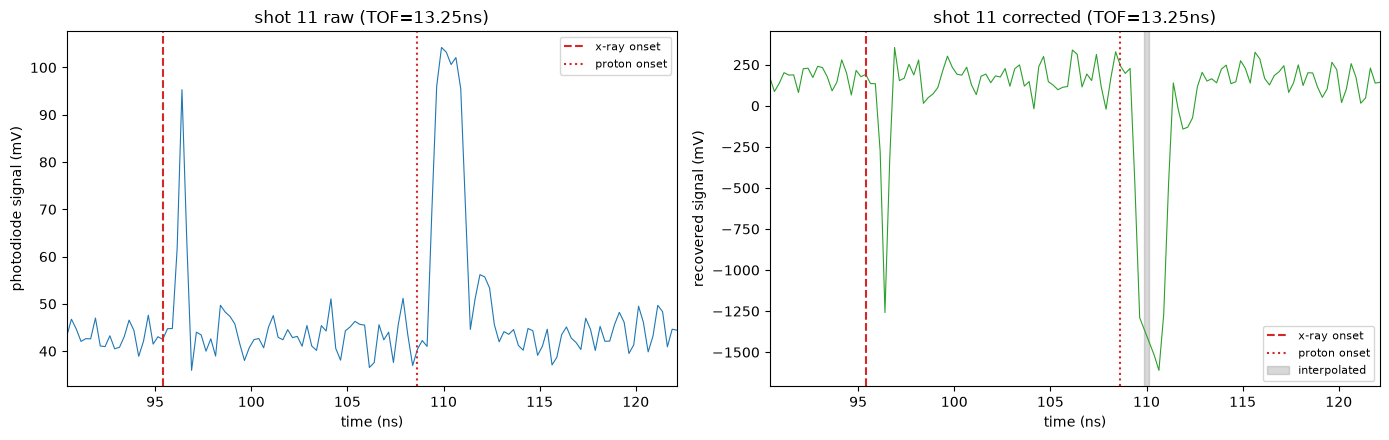

shot 19: Vmax=46.02mV (Vmax floor applied)  31 unstable samples  raw TOF=38.695ns  corrected TOF=38.961ns


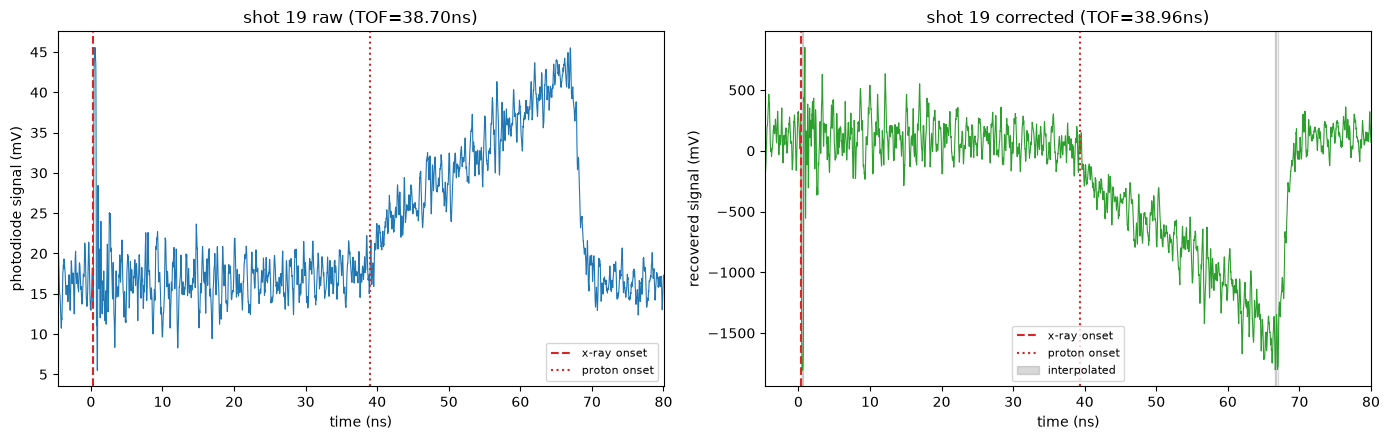

shot 20: Vmax=18.82mV (Vmax floor applied)  48 unstable samples  raw TOF=26.805ns  corrected TOF=26.859ns


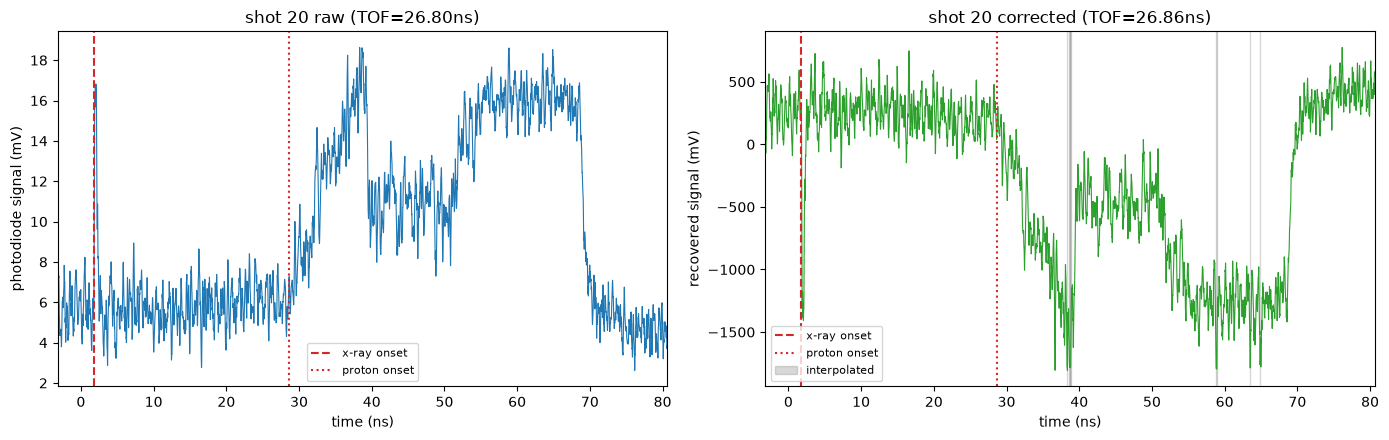

shot 21: Vmax=32.67mV (Vmax floor applied)  36 unstable samples  raw TOF=32.758ns  corrected TOF=32.852ns


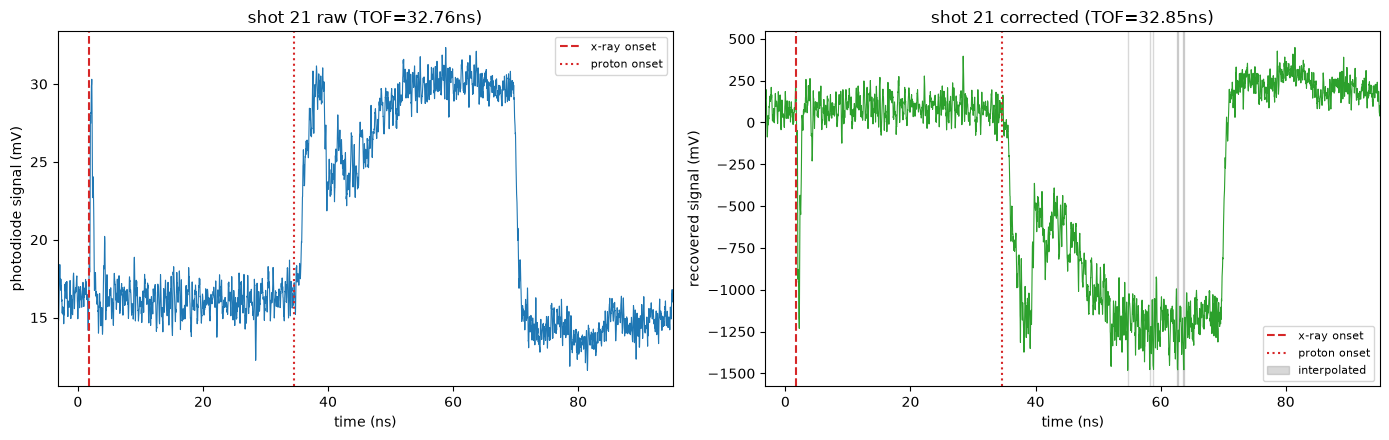

shot 27: Vmax=44.47mV (Vmax floor applied)  33 unstable samples  raw TOF=34.273ns  corrected TOF=33.680ns


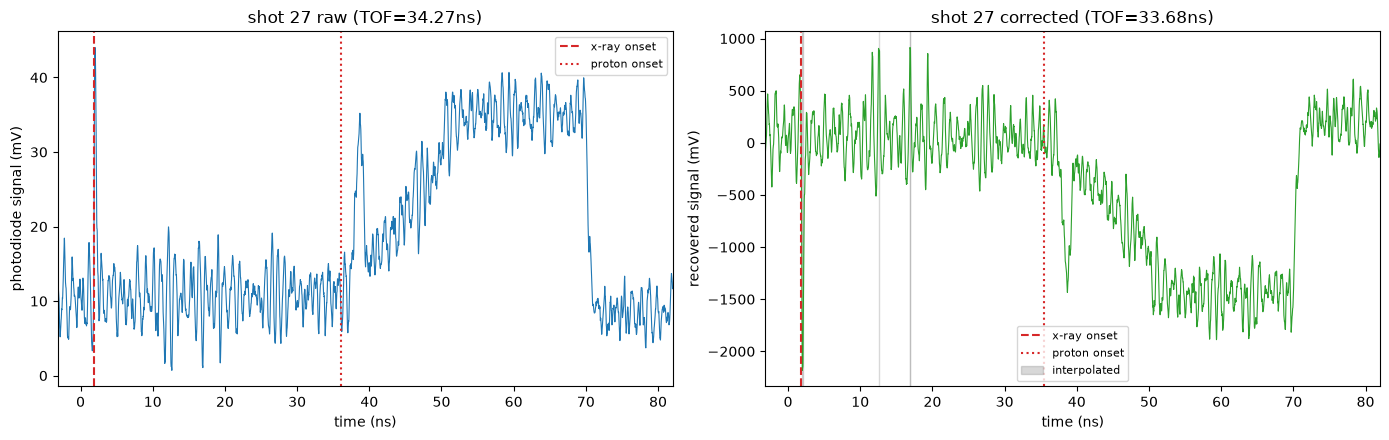

In [3]:
EOM_BIAS = {9: 1.2, 11: 1.3, 19: 1.6, 20: 1.6, 21: 1.1, 27: 2.2}
SKIPPED_NO_BIAS_LOGGED = [15, 16, 18, 22]

rows = []
for shot, V_bias in EOM_BIAS.items():
    if shot == 9:
        continue  # already shown above
    rows.append(plot_shot_correction(shot, V_bias))


## Summary table

In [4]:
all_rows = []
for shot, V_bias in EOM_BIAS.items():
    t, v, clipped, t_ns, result = load_and_correct(shot, V_bias)
    v_c = result["v_signal"]
    res_raw = characterize(t, v, clipped)
    xr_raw = find_xray_shape(t, v, res_raw["baseline_V"], res_raw["noise_V"])
    pr_raw = find_proton_onset(t, v, res_raw["baseline_V"], xr_raw["peak_i"])
    res_c = characterize(t, v_c, clipped)
    xr_c = find_xray_shape(t, v_c, res_c["baseline_V"], res_c["noise_V"])
    pr_c = find_proton_onset(t, v_c, res_c["baseline_V"], xr_c["peak_i"])
    tof_raw = pr_raw["onset_time_ns"] - xr_raw["onset_time_ns"]
    tof_c = pr_c["onset_time_ns"] - xr_c["onset_time_ns"]
    pulse_mask = (t_ns >= xr_raw["onset_time_ns"]) & (t_ns <= pr_raw["end_time_ns"])
    pct_unstable_in_pulse = 100*result["unstable_mask"][pulse_mask].sum()/pulse_mask.sum()
    all_rows.append(dict(
        shot=shot, V_bias=V_bias, Vmax_mV=round(result["Vmax"]*1000, 2),
        vmax_floor_applied=result["vmax_floor_applied"],
        pct_unstable_in_pulse=round(pct_unstable_in_pulse, 1),
        tof_raw_ns=round(tof_raw, 3), tof_corrected_ns=round(tof_c, 3),
        tof_pct_change=round(100*(tof_c-tof_raw)/tof_raw, 2),
    ))

summary_df = pd.DataFrame(all_rows).set_index("shot")
summary_df


,V_bias,Vmax_mV,vmax_floor_applied,pct_unstable_in_pulse,tof_raw_ns,tof_corrected_ns,tof_pct_change
shot,,,,,,,
9,1.2,68.89,True,9.8,12.500,12.547,0.38
11,1.3,105.28,True,2.9,13.250,13.250,0.00
19,1.6,46.02,True,0.3,38.695,38.961,0.69
20,1.6,18.82,True,0.5,26.805,26.859,0.20
21,1.1,32.67,True,0.3,32.758,32.852,0.29
27,2.2,44.47,True,0.4,34.273,33.680,-1.73


## Result

`φ0=54.4°` (refit value) applied across all 6 correctable shots. TOF changes by a
small percentage in every case -- consistent with the shot 9 finding that onset-based
timing doesn't depend much on getting `Vmax`/`φ0` exactly right, since threshold
crossings happen away from the unstable region.

The model-derived `Vmax` alone put several shots' peak transmission *above* 100%
(physically impossible -- direct proof `Vmax` was too low, not evidence of real
saturation), pushing 26-37% of some shots' pulses into the "unreliable" zone. Flooring
`Vmax` at what the data itself demands (see `pockels.py`) drops every shot to under
10% (most under 1%) flagged unstable.

Shots 15, 16, 18, 22 remain uncorrected pending an EOM bias voltage in the shot log.